<a href="https://colab.research.google.com/github/mannapoorani052-glitch/project-1/blob/main/NM_Internship_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded=files.upload()

import pandas as pd
df=pd.read_csv("sales dataset.csv")
print(df.head())



Saving sales dataset.csv to sales dataset (1).csv
   OrderID   OrderDate CustomerID     Product     Category  Quantity    Price  \
0     1001  05-01-2025       C001      Laptop  Electronics       2.0  55000.0   
1     1002  08-01-2025       C002       Mouse  Electronics       5.0    500.0   
2     1003  10-01-2025       C003    Keyboard  Electronics       3.0   1200.0   
3     1004  15-01-2025       C004  Headphones  Electronics       4.0   1500.0   
4     1005  02-02-2025       C005  Smartphone  Electronics       2.0  25000.0   

  Month  
0   Jan  
1   Feb  
2   Mar  
3   Apr  
4   May  


In [ ]:
print("\n Missing Values")
print(df.isnull().sum())


 Missing Values
OrderID       0
OrderDate     1
CustomerID    0
Product       2
Category      0
Quantity      2
Price         3
Month         0
dtype: int64


In [ ]:
#CHECK DUPLICATES RECORDS
print("\nDuplicates Rows:")
print(df.duplicated().sum())


Duplicates Rows:
0


**DATA CLEANING**

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Fill missing Product names
df["Product"] = df["Product"].fillna("Unknown")

# Fill missing Quantity
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())

# Fill missing Price
df["Price"] = df["Price"].fillna(df["Price"].median())

# Fill missing dates
df["OrderDate"] = df["OrderDate"].fillna(method='ffill')

# Standardize product names
df["Product"] = df["Product"].str.title()

print("\nCleaned dataset:")
print(df.head())


Cleaned dataset:
   OrderID   OrderDate CustomerID     Product     Category  Quantity    Price  \
0     1001  05-01-2025       C001      Laptop  Electronics       2.0  55000.0   
1     1002  08-01-2025       C002       Mouse  Electronics       5.0    500.0   
2     1003  10-01-2025       C003    Keyboard  Electronics       3.0   1200.0   
3     1004  15-01-2025       C004  Headphones  Electronics       4.0   1500.0   
4     1005  02-02-2025       C005  Smartphone  Electronics       2.0  25000.0   

  Month  
0   Jan  
1   Feb  
2   Mar  
3   Apr  
4   May  


/tmp/ipykernel_821/3020533966.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["OrderDate"] = df["OrderDate"].fillna(method='ffill')


In [ ]:
#CREATE REVENUE COLUMN

df["Revenue"] = df["Quantity"] * df["Price"]

print("\nRevenue Added")
print(df.head())


Revenue Added
   OrderID   OrderDate CustomerID     Product     Category  Quantity    Price  \
0     1001  05-01-2025       C001      Laptop  Electronics       2.0  55000.0   
1     1002  08-01-2025       C002       Mouse  Electronics       5.0    500.0   
2     1003  10-01-2025       C003    Keyboard  Electronics       3.0   1200.0   
3     1004  15-01-2025       C004  Headphones  Electronics       4.0   1500.0   
4     1005  02-02-2025       C005  Smartphone  Electronics       2.0  25000.0   

  Month   Revenue  
0   Jan  110000.0  
1   Feb    2500.0  
2   Mar    3600.0  
3   Apr    6000.0  
4   May   50000.0  


In [ ]:
#TOP SELLING PRODUCTS

top_products = df.groupby("Product")["Revenue"].sum()

top_products = top_products.sort_values(ascending=False)

print("\nTop Selling Products")
print(top_products)



Top Selling Products
Product
Laptop        385000.0
Smartphone    200000.0
Headphones    162000.0
Mouse          79000.0
Keyboard       78600.0
Unknown        56000.0
Name: Revenue, dtype: float64


In [ ]:
#MONTHLY SALES ANALYSIS

df["OrderDate"] = pd.to_datetime(df["OrderDate"], format="%d-%m-%Y")

df["Month"] = df["OrderDate"].dt.month_name()

monthly_sales = df.groupby("Month")["Revenue"].sum()

print("\nMonthly Sales")
print(monthly_sales)


Monthly Sales
Month
August       296000.0
February      50000.0
January      122100.0
July         100000.0
June         192500.0
October       50000.0
September    150000.0
Name: Revenue, dtype: float64


In [ ]:
#HIGHEST REVENUE PRODUCT

best_product = top_products.idxmax()

print("\nHighest Revenue Product:")
print(best_product)


Highest Revenue Product:
Laptop


In [ ]:
#HIGHEST REVENUE MONTH

best_month = monthly_sales.idxmax()

print("\nHighest Revenue Month:")
print(best_month)


Highest Revenue Month:
August


**BAR** **CHART**

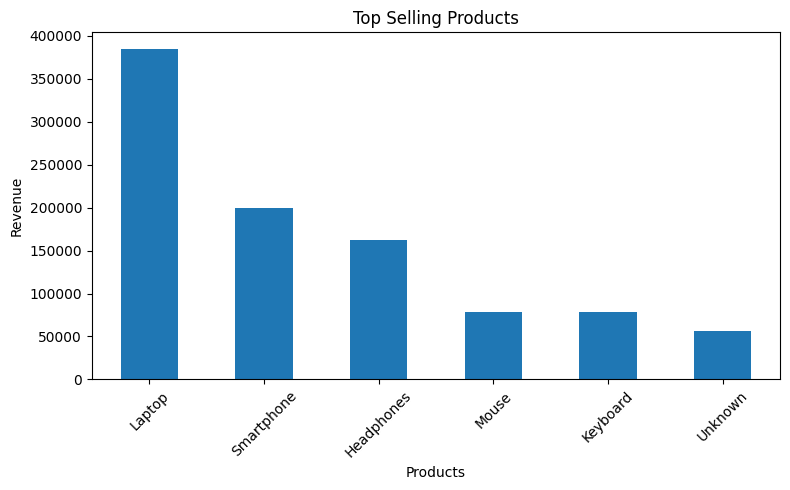

In [ ]:
plt.figure(figsize=(8,5))
top_products.plot(kind='bar')
plt.title("Top Selling Products")
plt.xlabel("Products")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**LINE CHART**

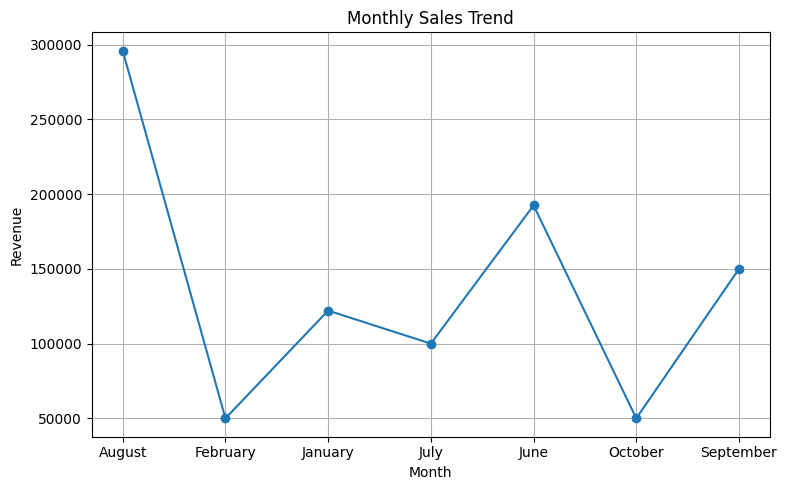

In [ ]:
plt.figure(figsize=(8,5))

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# KPI Metrics

total_revenue = df["Revenue"].sum()
total_orders = df["OrderID"].nunique()

top_product = top_products.idxmax()
best_month = monthly_sales.idxmax()

print("====== E-COMMERCE DASHBOARD ======")
print("Total Revenue :", total_revenue)
print("Total Orders :", total_orders)
print("Top Product :", top_product)
print("Best Sales Month :", best_month)

====== E-COMMERCE DASHBOARD ======
Total Revenue : 960600.0
Total Orders : 16
Top Product : Laptop
Best Sales Month : August


**DASHBOARD**

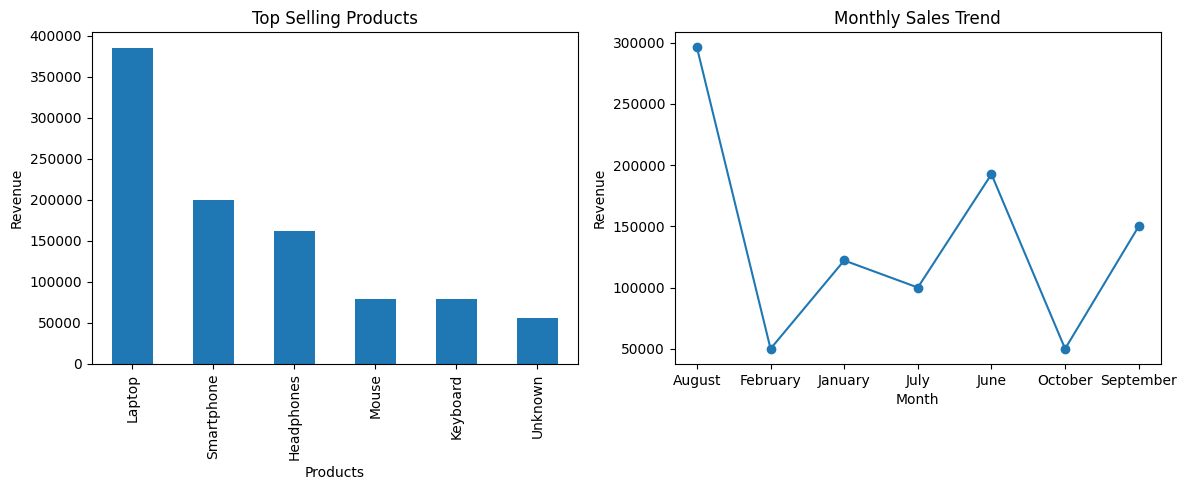

In [ ]:
import matplotlib.pyplot as pl
# Dashboard Size-
plt.figure(figsize=(12,5))
# Chart 1 - Bar Chart
plt.subplot(1,2,1)
top_products.plot(
    kind='bar'
)

plt.title("Top Selling Products")
plt.xlabel("Products")
plt.ylabel("Revenue")
# Chart 2 - Line Chart
plt.subplot(1,2,2)

monthly_sales.plot(
    kind='line',
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()